# Analisis Data Eksploratif (EDA) Bisnis - Delay Penerbangan

Notebook ini digunakan untuk menjawab tren delay, perilaku maskapai, dan waktu rawan berdasarkan data dari ClickHouse

In [1]:
import clickhouse_connect
import matplotlib.pyplot as plt
import gc

# Koneksi ke ClickHouse AWS EC2
client = clickhouse_connect.get_client(
    host='13.215.79.3', 
    username='default', 
    password='rahasia123',
    port=8123
)
print("✅ Berhasil terhubung ke ClickHouse!")

✅ Berhasil terhubung ke ClickHouse!


## Tren Delay Per Tahun

Menghitung tren delay per tahun...


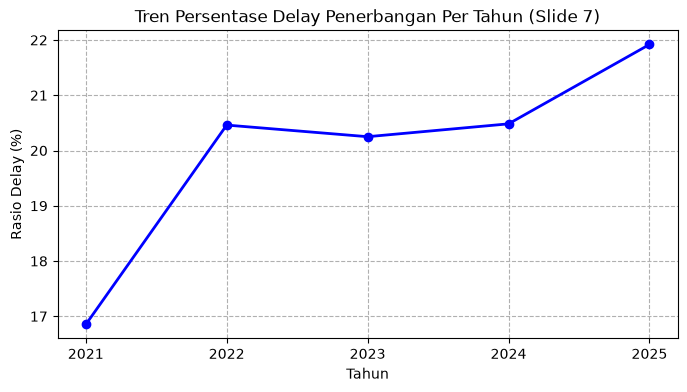

2461

In [3]:
print("Menghitung tren delay per tahun...")
query_tren = """
    SELECT 
        flight_year, 
        COUNT(*) as total_penerbangan,
        SUM(arr_del15_label) as total_delay,
        (SUM(arr_del15_label) / COUNT(*)) * 100 as rasio_delay_persen
    FROM flight_delay.ontime_features
    GROUP BY flight_year
    ORDER BY flight_year ASC
"""
res_tren = client.query_df(query_tren)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.plot(res_tren['flight_year'].astype(str), res_tren['rasio_delay_persen'], marker='o', color='b', linewidth=2)
plt.title('Tren Persentase Delay Penerbangan Per Tahun (Slide 7)')
plt.xlabel('Tahun')
plt.ylabel('Rasio Delay (%)')
plt.grid(True, linestyle='--')
plt.savefig("tren_delay_tahunan.png", dpi=150)
plt.show()
plt.close()

# Bersihkan RAM
del res_tren
gc.collect()

## Perilaku Maskapai / Top 10 Paling Sering Delay

Menghitung perilaku delay per maskapai...


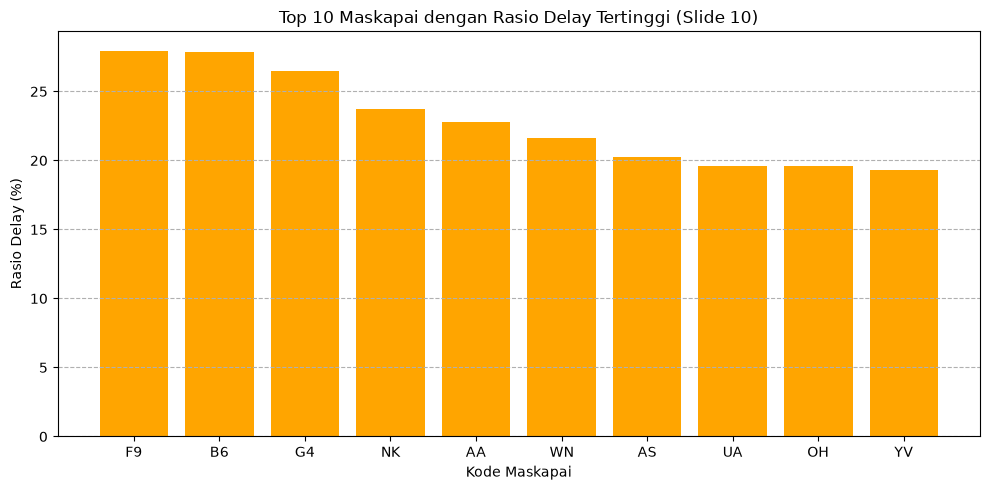

3250

In [4]:
print("Menghitung perilaku delay per maskapai...")
query_airline = """
    SELECT 
        IATA_CODE_Reporting_Airline as maskapai, 
        COUNT(*) as total_flight,
        SUM(arr_del15_label) as total_delay,
        (SUM(arr_del15_label) / COUNT(*)) * 100 as rasio_delay
    FROM flight_delay.ontime_features
    GROUP BY maskapai
    ORDER BY rasio_delay DESC
    LIMIT 10
"""
res_airline = client.query_df(query_airline)

# Visualisasi
plt.figure(figsize=(10, 5))
plt.bar(res_airline['maskapai'], res_airline['rasio_delay'], color='orange')
plt.title('Top 10 Maskapai dengan Rasio Delay Tertinggi (Slide 10)')
plt.xlabel('Kode Maskapai')
plt.ylabel('Rasio Delay (%)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig("delay_per_maskapai.png", dpi=150)
plt.show()
plt.close()

# Bersihkan RAM
del res_airline
gc.collect()

## Waktu Rawan/Jam Keberangkatan yang Sering Delay

Menghitung rasio delay berdasarkan waktu keberangkatan...


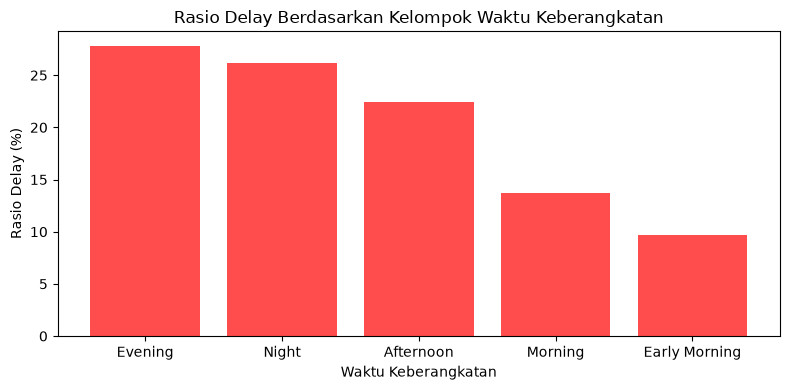

✅ Semua grafik EDA berhasil disimpan dan koneksi ditutup!


In [6]:
print("Menghitung rasio delay berdasarkan waktu keberangkatan...")
query_waktu = """
    SELECT 
        dep_time_bucket, 
        COUNT(*) as total_flight,
        (SUM(arr_del15_label) / COUNT(*)) * 100 as rasio_delay
    FROM flight_delay.ontime_features
    GROUP BY dep_time_bucket
    ORDER BY rasio_delay DESC
"""
res_waktu = client.query_df(query_waktu)

# Visualisasi
plt.figure(figsize=(8, 4))
plt.bar(res_waktu['dep_time_bucket'], res_waktu['rasio_delay'], color='red', alpha=0.7)
plt.title('Rasio Delay Berdasarkan Kelompok Waktu Keberangkatan')
plt.xlabel('Waktu Keberangkatan')
plt.ylabel('Rasio Delay (%)')
plt.tight_layout()
plt.savefig("waktu_rawan_delay.png", dpi=150)
plt.show()
plt.close()

# Tutup Koneksi
client.close()
print("✅ Semua grafik EDA berhasil disimpan dan koneksi ditutup!")